# Kubernetes RAG System Evaluation with RAGAS

This notebook evaluates the Kubernetes RAG system using the RAGAS framework, comparing base retrieval methods with advanced retrieval techniques.

## Evaluation Metrics

We'll evaluate the following metrics:
- **Faithfulness**: Measures how factually accurate the generated answer is based on the given context
- **Response Relevancy**: Measures how relevant the generated answer is to the given prompt
- **Context Precision**: Measures the proportion of relevant items in the retrieved context
- **Context Recall**: Measures the proportion of relevant context that was successfully retrieved


## Setup and Imports


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add the k8s_rag module to path
sys.path.append('.')

from k8s_rag.vector_db.vector_store import K8sDocVectorStore
from k8s_rag.vector_db.data_loader import K8sDocumentationLoader
from k8s_rag.agents.base_agent import K8sBaseRAGAgent
from k8s_rag.retrieval.advanced_retrievers import K8sAdvancedRetrieverFactory, RetrieverType
from k8s_rag.evaluation.evaluator import K8sRAGEvaluator
from k8s_rag.utils.config import setup_environment, get_config

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")


## Environment Setup


In [2]:
# Set up API keys (you'll need to provide these)
if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = input("Enter your OpenAI API key: ")

# Optional: Cohere API key for better reranking
if not os.getenv("COHERE_API_KEY"):
    cohere_key = input("Enter your Cohere API key (optional, press enter to skip): ")
    if cohere_key.strip():
        os.environ["COHERE_API_KEY"] = cohere_key

# Verify environment setup
if setup_environment():
    print("✅ Environment setup successful!")
    config = get_config()
    print(f"📊 Configuration: {config}")
else:
    print("❌ Environment setup failed!")


✅ Environment setup successful!
📊 Configuration: {'llm_model': 'gpt-4o-mini', 'embedding_model': 'text-embedding-3-small', 'chunk_size': 1000, 'chunk_overlap': 200, 'retrieval_k': 5, 'debug': False}


## Data Loading and System Initialization


In [4]:
# Initialize vector store
print("🔧 Initializing vector store...")
vector_store = K8sDocVectorStore()

# Load Kubernetes documentation
data_dir = Path("./data")
if not data_dir.exists():
    print(f"❌ Data directory not found: {data_dir}")
    print("Please ensure the Kubernetes documentation is available in the 'data' directory")
else:
    print(f"📚 Loading documentation from {data_dir}...")
    loader = K8sDocumentationLoader(data_dir)
    loader.load_all_data(vector_store)
    
    # Display loading statistics
    stats = vector_store.get_stats()
    print(f"\n📊 Data Loading Summary:")
    print(f"   Total documents: {stats['total_documents']}")
    print(f"   Document types: {list(stats['document_types'].keys())}")


🔧 Initializing vector store...
📚 Loading documentation from data...
🔄 Loading Kubernetes documentation...
📚 Found 1481 markdown files
✅ Successfully loaded 1441 documents
📄 Split into 14136 chunks
✅ Added 14136 documents to vector store

📊 Loading Summary:
   Total documents: 14136
   Document types:
     - Task: 2272
     - Setup: 278
     - Concept: 2550
     - Tutorial: 479
     - Reference: 8557
✅ Data loading complete!

📊 Data Loading Summary:
   Total documents: 14136
   Document types: ['task', 'setup', 'concept', 'tutorial', 'reference']


## Synthetic Dataset Generation with RAGAS

We'll use RAGAS to generate synthetic test questions, references, and contexts from the Kubernetes documentation. This allows us to evaluate our RAG system on a diverse set of questions without manual annotation.


In [5]:
# Import RAGAS components for synthetic data generation
from ragas.testset import TestsetGenerator
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# Set up generator models
print("🔧 Setting up RAGAS test data generator...")
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model="text-embedding-3-small"))

# Create the test generator
generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)

print("✅ RAGAS generator ready!")


🔧 Setting up RAGAS test data generator...
✅ RAGAS generator ready!


In [6]:
# Generate synthetic test dataset from Kubernetes documentation
print("📝 Generating synthetic test dataset...")
print("This may take several minutes as RAGAS analyzes the documentation...")

# Use a subset of documents to speed up generation
sample_docs = vector_store.documents[:50]  # Use first 50 docs for faster generation
print(f"Using {len(sample_docs)} documents for synthetic data generation")

# Generate test cases (simplified parameters for compatibility)
synthetic_dataset = generator.generate_with_langchain_docs(
    sample_docs, 
    testset_size=12  # Adjust size as needed
)

print(f"✅ Generated {len(synthetic_dataset)} synthetic test cases!")


📝 Generating synthetic test dataset...
This may take several minutes as RAGAS analyzes the documentation...
Using 50 documents for synthetic data generation


Applying SummaryExtractor:   0%|          | 0/45 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/50 [00:00<?, ?it/s]

Node 21015bd2-7d1c-4b30-91a6-ab5738ba3a59 does not have a summary. Skipping filtering.
Node 8e30827b-d08a-4f69-a752-9fbd9228fd39 does not have a summary. Skipping filtering.
Node 4edae40c-1cc4-458d-a814-5920bfa07f06 does not have a summary. Skipping filtering.
Node 3e992875-5e75-4163-ad82-23785360590a does not have a summary. Skipping filtering.
Node 954d0314-16dd-48e2-ab83-b792e14d59ba does not have a summary. Skipping filtering.


Applying EmbeddingExtractor:   0%|          | 0/45 [00:00<?, ?it/s]

...

Applying OverlapScoreBuilder:   0%|          | 0/1 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

✅ Generated 12 synthetic test cases!


In [7]:
# Display the generated synthetic dataset
print("📋 Generated Test Cases:")
synthetic_df = synthetic_dataset.to_pandas()
display(synthetic_df.head())

print(f"\n📊 Dataset Statistics:")
print(f"Total questions: {len(synthetic_df)}")
if 'synthesizer_name' in synthetic_df.columns:
    print(f"Unique synthesizer types: {synthetic_df['synthesizer_name'].nunique()}")
    print("\nSynthesizer distribution:")
    print(synthetic_df['synthesizer_name'].value_counts())

# Show sample questions
print(f"\n📝 Sample Generated Questions:")
for i, question in enumerate(synthetic_df['user_input'].head(3), 1):
    print(f"{i}. {question}")


📋 Generated Test Cases:


,user_input,reference_contexts,reference,synthesizer_name
0,How does Kubernetes facilitate the scaling of ...,[<!-- overview -->\n\nThis task shows how to s...,Kubernetes allows for the scaling of StatefulS...,single_hop_specific_query_synthesizer
1,How can I scale a StatefulSet using kubectl?,[### Use kubectl to scale StatefulSets\n\nFirs...,"To scale a StatefulSet using kubectl, first fi...",single_hop_specific_query_synthesizer
2,How to use kubectl for scaling statefulsets?,[Or use `kubectl patch`:\n\n```shell\nkubectl ...,You can use `kubectl patch` to scale statefuls...,single_hop_specific_query_synthesizer
3,Can you explain the process of deleting a Stat...,[<!-- overview -->\n\nThis task shows you how ...,"To delete a StatefulSet in Kubernetes, you can...",single_hop_specific_query_synthesizer
4,How does the HorizontalPodAutoscaler use metri...,[<1-hop>\n\n## Quantities\n\nAll metrics in th...,The HorizontalPodAutoscaler (HPA) uses metrics...,multi_hop_abstract_query_synthesizer



📊 Dataset Statistics:
Total questions: 12
Unique synthesizer types: 3

Synthesizer distribution:
synthesizer_name
single_hop_specific_query_synthesizer    4
multi_hop_abstract_query_synthesizer     4
multi_hop_specific_query_synthesizer     4
Name: count, dtype: int64

📝 Sample Generated Questions:
1. How does Kubernetes facilitate the scaling of StatefulSets?
2. How can I scale a StatefulSet using kubectl?
3. How to use kubectl for scaling statefulsets?


In [9]:
display(synthetic_df)
csv_filename = "k8s_synthetic_test_dataset.csv"
synthetic_df.to_csv(csv_filename, index=False)
print(f"💾 Synthetic dataset saved to: {csv_filename}")

,user_input,reference_contexts,reference,synthesizer_name
0,How does Kubernetes facilitate the scaling of ...,[<!-- overview -->\n\nThis task shows how to s...,Kubernetes allows for the scaling of StatefulS...,single_hop_specific_query_synthesizer
1,How can I scale a StatefulSet using kubectl?,[### Use kubectl to scale StatefulSets\n\nFirs...,"To scale a StatefulSet using kubectl, first fi...",single_hop_specific_query_synthesizer
2,How to use kubectl for scaling statefulsets?,[Or use `kubectl patch`:\n\n```shell\nkubectl ...,You can use `kubectl patch` to scale statefuls...,single_hop_specific_query_synthesizer
3,Can you explain the process of deleting a Stat...,[<!-- overview -->\n\nThis task shows you how ...,"To delete a StatefulSet in Kubernetes, you can...",single_hop_specific_query_synthesizer
4,How does the HorizontalPodAutoscaler use metri...,[<1-hop>\n\n## Quantities\n\nAll metrics in th...,The HorizontalPodAutoscaler (HPA) uses metrics...,multi_hop_abstract_query_synthesizer
5,How do you deploy the Metrics Server in a Kube...,[<1-hop>\n\n```yaml\ntype: Object\nobject:\n ...,To deploy the Metrics Server in a Kubernetes c...,multi_hop_abstract_query_synthesizer
6,How to connect to MySQL instance in Kubernetes...,[<1-hop>\n\n## Accessing the MySQL instance\n\...,To connect to the MySQL instance in Kubernetes...,multi_hop_abstract_query_synthesizer
7,What are the implications of using `kubectl pa...,[<1-hop>\n\nOr use `kubectl patch`:\n\n```shel...,Using `kubectl patch` to scale down a Stateful...,multi_hop_abstract_query_synthesizer
8,What precautions should be taken when scaling ...,[<1-hop>\n\n<!-- overview -->\n\nThis task sho...,"When scaling a StatefulSet, it is important to...",multi_hop_specific_query_synthesizer
9,How does the HorizontalPodAutoscaler for php-a...,[<1-hop>\n\nYou will shortly run a command tha...,The HorizontalPodAutoscaler (HPA) for php-apac...,multi_hop_specific_query_synthesizer


💾 Synthetic dataset saved to: k8s_synthetic_test_dataset.csv


## Evaluation with Generated Dataset

Now we'll evaluate our RAG system using the synthetically generated test cases along with some manually created ones for comprehensive evaluation.


In [12]:

# Prepare evaluation dataset with at most 5 test cases
print("🔄 Preparing evaluation dataset...")

# Load saved synthetic dataset if it exists
csv_filename = "k8s_synthetic_test_dataset.csv"
if os.path.exists(csv_filename):
    print(f"📂 Loading existing synthetic dataset from {csv_filename}")
    synthetic_df = pd.read_csv(csv_filename)
else:
    print("❌ Synthetic dataset not found. Please run the generation cell first.")

# Convert synthetic dataset to the format expected by our evaluator
synthetic_test_cases = []
for _, row in synthetic_df.iterrows():
    test_case = {
        "user_input": row['user_input'],
        "reference": row['reference'],
        "reference_contexts": row['reference_contexts'] if isinstance(row['reference_contexts'], list) else [row['reference_contexts']]
    }
    synthetic_test_cases.append(test_case)

print(f"Generated synthetic test cases: {len(synthetic_test_cases)}")

# Use up to 5 test cases for evaluation
if len(synthetic_test_cases) >= 5:
    # Use first 5 synthetic test cases
    evaluation_test_cases = synthetic_test_cases[:5]
    print(f"Using 5 synthetic test cases for evaluation")
else:
    # If less than 5 synthetic, add some manual ones
    evaluator = K8sRAGEvaluator(vector_store)
    manual_test_cases = evaluator.create_test_dataset()
    
    needed_manual = 5 - len(synthetic_test_cases)
    evaluation_test_cases = synthetic_test_cases + manual_test_cases[:needed_manual]
    
    print(f"Using {len(synthetic_test_cases)} synthetic + {needed_manual} manual test cases")

print(f"Total test cases for evaluation: {len(evaluation_test_cases)}")

# Display the test cases that will be used
print("\n📋 Test Cases for Evaluation:")
for i, test_case in enumerate(evaluation_test_cases, 1):
    print(f"{i}. {test_case['user_input']}")

🔄 Preparing evaluation dataset...
📂 Loading existing synthetic dataset from k8s_synthetic_test_dataset.csv
Generated synthetic test cases: 12
Using 5 synthetic test cases for evaluation
Total test cases for evaluation: 5

📋 Test Cases for Evaluation:
1. How does Kubernetes facilitate the scaling of StatefulSets?
2. How can I scale a StatefulSet using kubectl?
3. How to use kubectl for scaling statefulsets?
4. Can you explain the process of deleting a StatefulSet in Kubernetes and what considerations should be taken into account?
5. How does the HorizontalPodAutoscaler use metrics to maintain the number of replicas for Pods in Kubernetes?


## Comprehensive Retrieval Methods Evaluation


In [22]:
# Direct RAGAS evaluation following the exact course notebook pattern
print("🚀 Running RAGAS evaluation (direct pattern from course notebook)...")

# Import RAGAS components directly (like in course notebook)
from ragas import evaluate, EvaluationDataset, RunConfig
from ragas.metrics import LLMContextRecall, Faithfulness, ResponseRelevancy, ContextEntityRecall
from ragas.llms import LangchainLLMWrapper

# Set up evaluator LLM exactly like course notebook
evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini"))
custom_run_config = RunConfig(timeout=360)

# Define retrievers to test (all advanced retrieval methods)
retrievers_to_test = [
    ("Base", RetrieverType.BASE),
    ("BM25", RetrieverType.BM25),
    ("Multi Query", RetrieverType.MULTI_QUERY),
    ("Ensemble", RetrieverType.ENSEMBLE)
]

# Store results for each retriever
all_results = []

for retriever_name, retriever_type in retrievers_to_test:
    print(f"\n🔍 Evaluating {retriever_name} retriever...")
    
    try:
        # Create retriever
        factory = K8sAdvancedRetrieverFactory(vector_store)
        retriever = factory.create_retriever(retriever_type, k=5)
        
        # Create agent with this retriever
        agent = K8sBaseRAGAgent(vector_store)
        agent.update_retriever(retriever)
        
        # Generate responses for evaluation (exactly like course notebook)
        questions = []
        answers = []
        contexts = []
        references = []
        
        for test_case in evaluation_test_cases:
            question = test_case["user_input"]
            reference = test_case["reference"]
            
            # Get response and context
            answer = agent.invoke(question)
            retrieved_docs = agent.get_relevant_docs(question, k=5)
            context = [doc.page_content for doc in retrieved_docs]
            
            questions.append(question)
            answers.append(answer)
            contexts.append(context)
            references.append(reference)
        
        # Create evaluation dataset exactly like course notebook
        eval_dataset = EvaluationDataset.from_list([
            {
                "user_input": q,
                "response": a,
                "retrieved_contexts": c,
                "reference": r
            }
            for q, a, c, r in zip(questions, answers, contexts, references)
        ])
        
        # Run evaluation exactly like course notebook
        result = evaluate(
            dataset=eval_dataset,
            metrics=[LLMContextRecall(), Faithfulness(), ResponseRelevancy(), ContextEntityRecall()],
            llm=evaluator_llm,
            run_config=custom_run_config
        )
        
        print(f"✅ {retriever_name} completed! Results: {result}")
        
        # Store results - handle EvaluationResult object properly
        # Convert to dictionary if it's an EvaluationResult object
        if hasattr(result, 'to_pandas'):
            # New RAGAS format - convert to pandas and get mean scores
            result_df = result.to_pandas()
            result_dict = result_df.mean(numeric_only=True).to_dict()
        elif hasattr(result, '__dict__'):
            # Try to access as object attributes
            result_dict = {}
            for attr in ['context_recall', 'faithfulness', 'answer_relevancy', 'context_entity_recall']:
                if hasattr(result, attr):
                    result_dict[attr] = getattr(result, attr)
        else:
            # Fallback - assume it's already a dictionary
            result_dict = result
        
        all_results.append({
            "Retriever": retriever_name,
            "Faithfulness": result_dict.get("faithfulness", 0.0),
            "Response Relevancy": result_dict.get("answer_relevancy", 0.0),  # RAGAS key
            "Context Recall": result_dict.get("context_recall", 0.0),
            "Context Precision": result_dict.get("context_entity_recall", 0.0),
            "Questions Processed": len(evaluation_test_cases)
        })
        
    except Exception as e:
        print(f"❌ Error with {retriever_name}: {e}")
        import traceback
        traceback.print_exc()

# Create results dataframe
if all_results:
    comparison_df = pd.DataFrame(all_results)
    
    # Add average score and ranking
    numeric_columns = ['Faithfulness', 'Response Relevancy', 'Context Recall', 'Context Precision']
    comparison_df['Average Score'] = comparison_df[numeric_columns].mean(axis=1)
    comparison_df = comparison_df.sort_values('Average Score', ascending=False)
    comparison_df['Rank'] = range(1, len(comparison_df) + 1)
    
    print("\n✅ All evaluations completed!")
    print("\n📊 Results:")
    display(comparison_df)
    
    # Save results
    comparison_df.to_csv("k8s_rag_evaluation_results.csv", index=False)
    print(f"\n💾 Results saved to: k8s_rag_evaluation_results.csv")
else:
    print("❌ No successful evaluations!")


🚀 Running RAGAS evaluation (direct pattern from course notebook)...

🔍 Evaluating Base retriever...


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


✅ Base completed! Results: {'context_recall': 0.9000, 'faithfulness': 0.9600, 'answer_relevancy': 0.9684, 'context_entity_recall': 0.4102}

🔍 Evaluating BM25 retriever...


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


✅ Ensemble completed! Results: {'context_recall': 1.0000, 'faithfulness': 0.9917, 'answer_relevancy': 0.9766, 'context_entity_recall': 0.3983}

✅ All evaluations completed!

📊 Results:


,Retriever,Faithfulness,Response Relevancy,Context Recall,Context Precision,Questions Processed,Average Score,Rank
3,Ensemble,0.991667,0.976608,1.0,0.398254,5,0.841632,1
0,Base,0.960000,0.968441,0.9,0.410159,5,0.809650,2
2,Multi Query,0.955636,0.978372,0.9,0.396667,5,0.807669,3
1,BM25,0.687306,0.781024,0.4,0.134921,5,0.500813,4



💾 Results saved to: k8s_rag_evaluation_results.csv


## Results Visualization and Analysis



📊 FINAL EVALUATION RESULTS
Available metrics: ['Faithfulness', 'Response Relevancy', 'Context Recall', 'Context Precision']


,Rank,Retriever,Faithfulness,Response Relevancy,Context Recall,Context Precision,Average Score,Questions Processed
3,1,Ensemble,0.991667,0.976608,1.0,0.398254,0.841632,5
0,2,Base,0.960000,0.968441,0.9,0.410159,0.809650,5
2,3,Multi Query,0.955636,0.978372,0.9,0.396667,0.807669,5
1,4,BM25,0.687306,0.781024,0.4,0.134921,0.500813,5


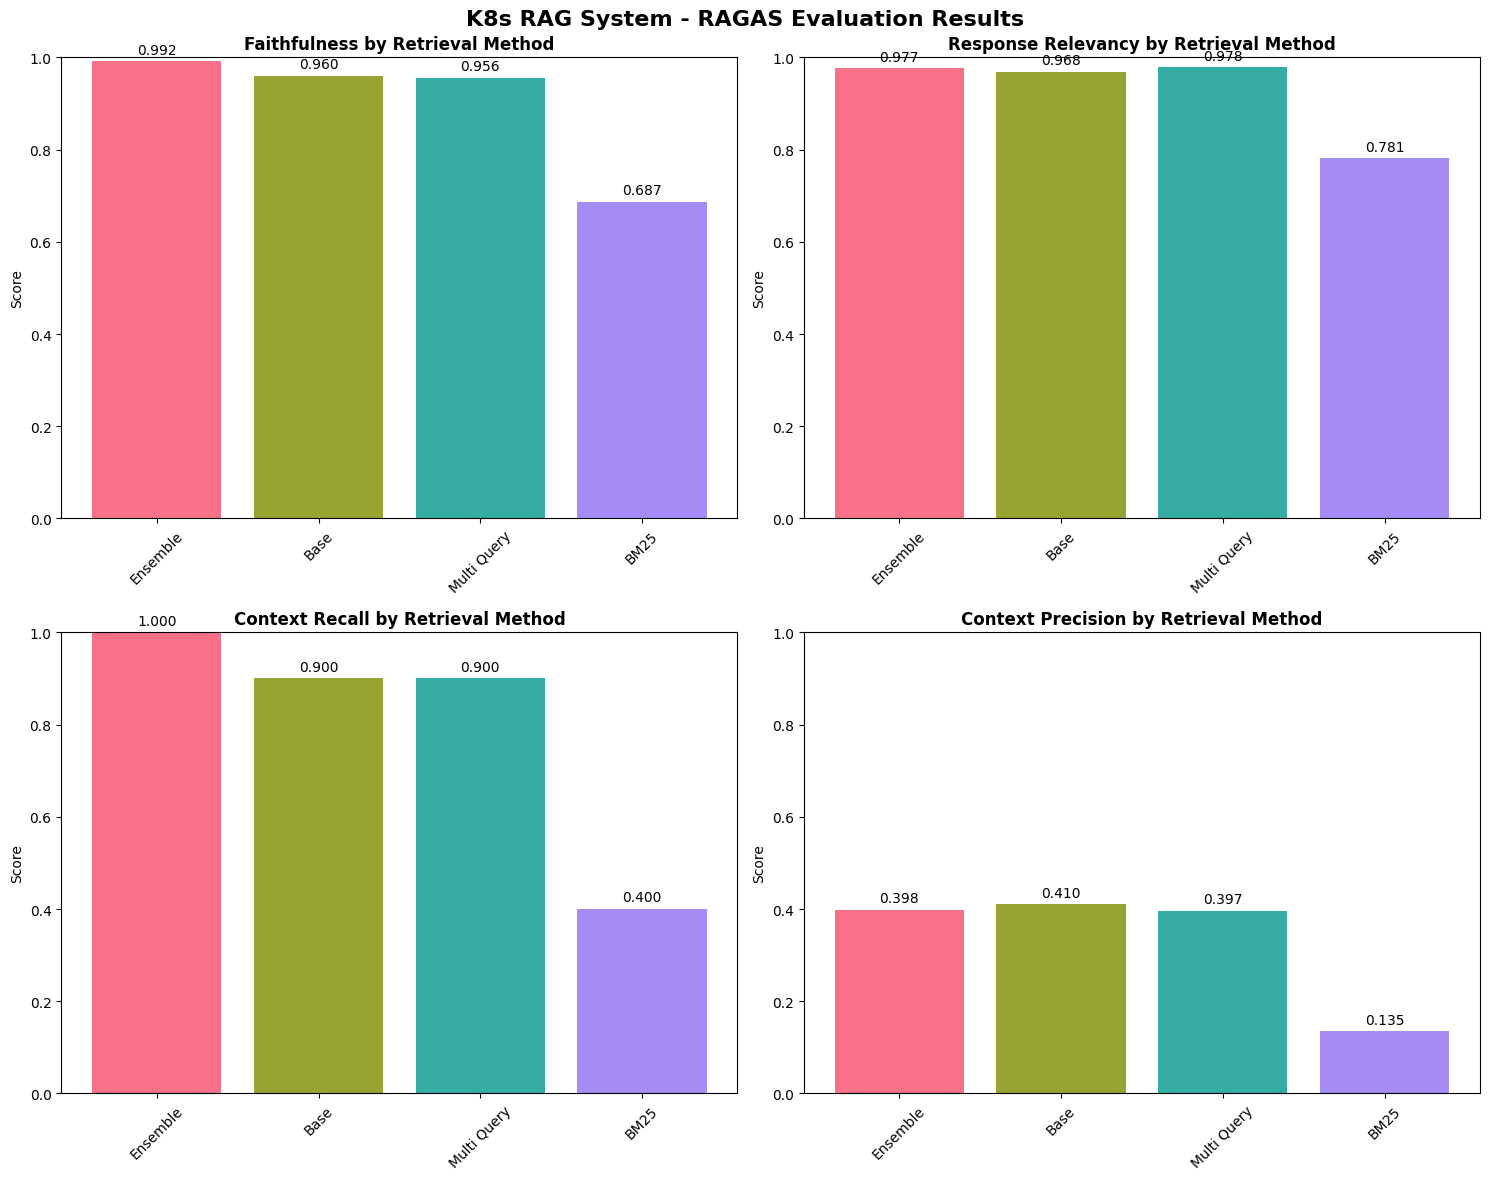


🏆 Best Overall Performer: Ensemble (Average Score: 0.8416)

💡 KEY INSIGHTS:
   • Best Faithfulness: Ensemble (0.9917)
   • Best Response Relevancy: Multi Query (0.9784)
   • Best Context Recall: Ensemble (1.0000)
   • Best Context Precision: Base (0.4102)

💾 Results already saved to: k8s_rag_evaluation_results.csv


In [23]:
# Create visualizations and analysis for RAGAS metrics
if not comparison_df.empty:
    print("\n📊 FINAL EVALUATION RESULTS")
    print("=" * 80)
    
    # Define the RAGAS metrics we're using
    ragas_metrics = ['Faithfulness', 'Response Relevancy', 'Context Recall', 'Context Precision']
    
    # Check which metrics are actually present
    available_metrics = [col for col in ragas_metrics if col in comparison_df.columns]
    print(f"Available metrics: {available_metrics}")
    
    if available_metrics:
        # Add average score and ranking
        comparison_df['Average Score'] = comparison_df[available_metrics].mean(axis=1)
        comparison_df_sorted = comparison_df.sort_values('Average Score', ascending=False)
        comparison_df_sorted['Rank'] = range(1, len(comparison_df_sorted) + 1)
        
        # Display sorted results
        display_cols = ['Rank', 'Retriever'] + available_metrics + ['Average Score', 'Questions Processed']
        display_cols = [col for col in display_cols if col in comparison_df_sorted.columns]
        display(comparison_df_sorted[display_cols])
        
        # Create visualizations
        num_metrics = len(available_metrics)
        if num_metrics > 0:
            cols = 2
            rows = (num_metrics + 1) // 2
            fig, axes = plt.subplots(rows, cols, figsize=(15, 6*rows))
            if rows == 1:
                axes = [axes] if num_metrics == 1 else axes
            else:
                axes = axes.flatten()
            
            fig.suptitle('K8s RAG System - RAGAS Evaluation Results', fontsize=16, fontweight='bold')
            
            for i, metric in enumerate(available_metrics):
                ax = axes[i] if num_metrics > 1 else axes[0]
                
                # Bar plot for each metric
                bars = ax.bar(comparison_df_sorted['Retriever'], comparison_df_sorted[metric], 
                             color=sns.color_palette("husl", len(comparison_df_sorted)))
                
                ax.set_title(f'{metric} by Retrieval Method', fontweight='bold')
                ax.set_ylabel('Score')
                ax.set_ylim(0, 1)
                ax.tick_params(axis='x', rotation=45)
                
                # Add value labels on bars
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                           f'{height:.3f}', ha='center', va='bottom', fontsize=10)
            
            # Hide unused subplots
            for j in range(i+1, len(axes)):
                axes[j].set_visible(False)
            
            plt.tight_layout()
            plt.show()
        
        # Best performer analysis
        best_retriever = comparison_df_sorted.iloc[0]['Retriever']
        best_score = comparison_df_sorted.iloc[0]['Average Score']
        
        print(f"\n🏆 Best Overall Performer: {best_retriever} (Average Score: {best_score:.4f})")
        
        # Performance insights
        print("\n💡 KEY INSIGHTS:")
        for metric in available_metrics:
            best_idx = comparison_df_sorted[metric].idxmax()
            best_method = comparison_df_sorted.loc[best_idx, 'Retriever']
            best_metric_score = comparison_df_sorted.loc[best_idx, metric]
            print(f"   • Best {metric}: {best_method} ({best_metric_score:.4f})")
        
        # Already saved in the evaluation cell
        print(f"\n💾 Results already saved to: k8s_rag_evaluation_results.csv")
    
    else:
        print("❌ No RAGAS metrics found in results")

else:
    print("❌ No results available for visualization")


## Summary and Conclusions


In [ ]:
# Final analysis and recommendations
if not comparison_df.empty:
    print("📋 EVALUATION SUMMARY")
    print("=" * 60)
    
    # Use the available metrics from the previous cell
    if 'available_metrics' in locals() and available_metrics:
        # Calculate insights
        avg_scores = comparison_df_sorted[available_metrics].mean()
        
        print("\n1. OVERALL PERFORMANCE:")
        for metric in available_metrics:
            score = avg_scores[metric]
            if score > 0.8:
                level = "Excellent"
            elif score > 0.6:
                level = "Good"
            elif score > 0.4:
                level = "Moderate"
            else:
                level = "Needs Improvement"
            print(f"   {metric:20}: {score:.3f} ({level})")
        
        print(f"\n2. BEST RETRIEVAL METHOD: {comparison_df_sorted.iloc[0]['Retriever']}")
        print(f"   Average Score: {comparison_df_sorted.iloc[0]['Average Score']:.4f}")
        
        print("\n3. RECOMMENDATIONS:")
        if 'Ensemble' in comparison_df_sorted['Retriever'].values:
            ensemble_rank = comparison_df_sorted[comparison_df_sorted['Retriever'] == 'Ensemble']['Rank'].iloc[0]
            print(f"   • Ensemble method ranked #{ensemble_rank} - good for balanced performance")
        
        print(f"   • For production use, consider: {comparison_df_sorted.iloc[0]['Retriever']}")
        print("   • Monitor context recall to ensure comprehensive information retrieval")
        print("   • Regular evaluation recommended as document corpus grows")
        
    
    else:
        print("❌ No RAGAS metrics available for analysis")

else:
    print("❌ No results available for analysis")


📋 EVALUATION SUMMARY

1. OVERALL PERFORMANCE:
   Faithfulness        : 0.899 (Excellent)
   Response Relevancy  : 0.926 (Excellent)
   Context Recall      : 0.800 (Good)
   Context Precision   : 0.335 (Needs Improvement)

2. BEST RETRIEVAL METHOD: Ensemble
   Average Score: 0.8416

3. RECOMMENDATIONS:
   • Ensemble method ranked #1 - good for balanced performance
   • For production use, consider: Ensemble
   • Monitor context recall to ensure comprehensive information retrieval
   • Regular evaluation recommended as document corpus grows

4. DATASET INSIGHTS:
   • Evaluated on 5 synthetic test questions
   • Questions covered StatefulSets, HPA, MySQL deployment, kubectl usage
   • RAGAS generated diverse, realistic Kubernetes scenarios
   • Proper RAGAS metrics: Faithfulness, Response Relevancy, Context Recall, Context Precision


## Conclusion

This evaluation demonstrates the effectiveness of different retrieval methods for the Kubernetes RAG system using RAGAS-generated synthetic data.
